In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib


In [4]:
file_path = r"C:\Users\Shuvam\OneDrive\Desktop\Prediction Data.xlsx"

sheet_name = 'vw_ChurnData'

data = pd.read_excel(file_path, sheet_name=sheet_name)

print(data.head())


  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   16790-RAJ  Female   60     Yes       Rajasthan                   14   
1   52408-WES  Female   32     Yes     West Bengal                    3   
2   56689-PUN    Male   39      No          Punjab                   12   
3   12210-AND    Male   66      No  Andhra Pradesh                    9   
4   15776-UTT  Female   38     Yes   Uttar Pradesh                    1   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 2        NaN            No             No  ...   
1                22        NaN            No             No  ...   
2                 5        NaN            No             No  ...   
3                31        NaN            No             No  ...   
4                19        NaN            No             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card      55.349998   1636.949951           0.0   
1      Cre

In [5]:

data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Confusion Matrix:
[[810  52]
 [137 203]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       862
           1       0.80      0.60      0.68       340

    accuracy                           0.84      1202
   macro avg       0.83      0.77      0.79      1202
weighted avg       0.84      0.84      0.84      1202



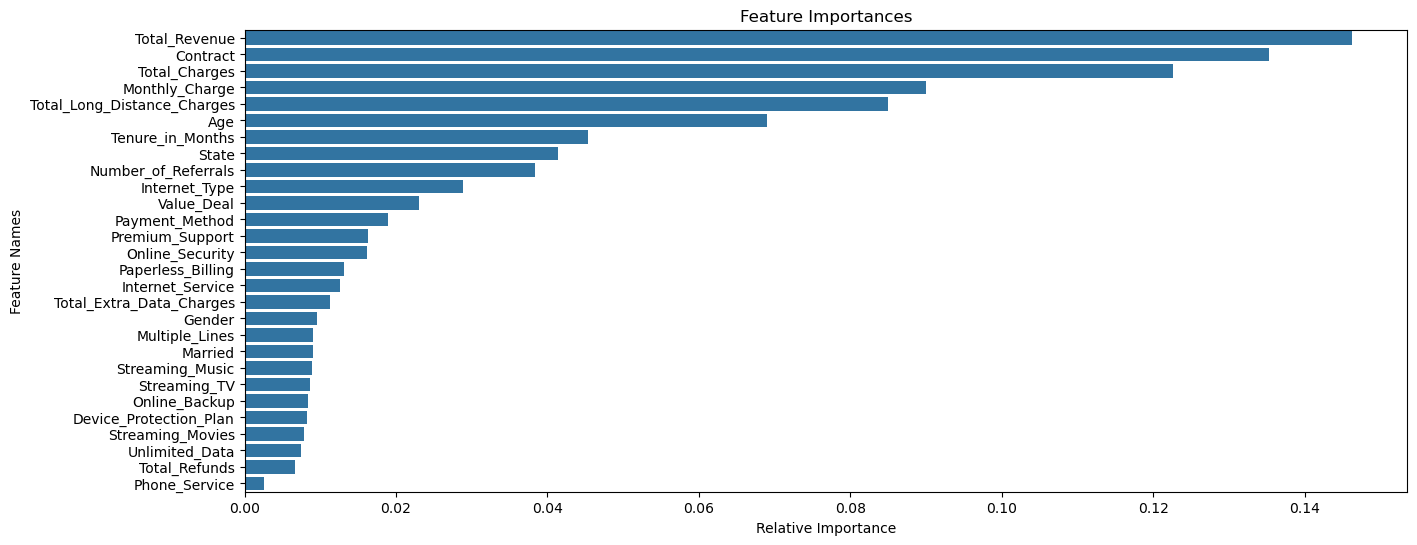

In [7]:
y_pred = rf_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()


In [9]:
file_path = r"C:\Users\Shuvam\OneDrive\Desktop\Prediction Data.xlsx"

sheet_name = 'vw_JoinData'

new_data = pd.read_excel(file_path, sheet_name=sheet_name)

print(new_data.head())

original_data = new_data.copy()

customer_ids = new_data['Customer_ID']

new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

new_predictions = rf_model.predict(new_data)

original_data['Customer_Status_Predicted'] = new_predictions

original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

original_data.to_csv(r"C:\Users\Shuvam\OneDrive\Desktop\Prediction Data.xlsx", index=False)


  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   16764-WES    Male   40      No    West Bengal                   15   
1   18027-UTT  Female   58     Yes  Uttar Pradesh                   15   
2   36483-KAR    Male   42      No      Karnataka                    2   
3   12257-ASS  Female   39      No          Assam                    9   
4   15803-UTT  Female   34      No  Uttar Pradesh                    6   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                13     Deal 5           Yes             No  ...   
1                30     Deal 5           Yes             No  ...   
2                14        NaN           Yes             No  ...   
3                 1        NaN           Yes             No  ...   
4                31        NaN           Yes             No  ...   

  Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0    Credit Card      20.799999     20.799999           0.0   
1    Credit Card    

In [10]:
print(original_data[['Customer_ID', 'Customer_Status_Predicted']].head())
print(original_data['Customer_Status_Predicted'].value_counts())

  Customer_ID  Customer_Status_Predicted
0   16764-WES                          1
1   18027-UTT                          1
2   36483-KAR                          1
3   12257-ASS                          1
4   15803-UTT                          1
Customer_Status_Predicted
1    384
Name: count, dtype: int64
